# SpatialData + Squidpy: spatial statistics

**Day 1 · Session 3**

Everything so far described the data. Now we ask the first genuinely spatial question: *which
cells sit next to which other cells, and is that arrangement surprising?*

Every answer in this notebook is a function of one object — the **spatial graph**. Build a
different graph and the biology changes. That is the lesson of the session, and the exercise
is designed to make you feel it rather than take our word for it.

### What you will be able to do afterwards

- Build a spatial neighbour graph three different ways, and say when each is appropriate
- Run and read a neighbourhood-enrichment analysis, including what its null model is
- Distinguish graph-resolved from distance-resolved statistics, and know when to use which

## Setup

We pick up the QC-filtered object saved at the end of Session 2.1. If you did not finish that
notebook, the next cell reapplies the same filter instead, so you can carry on either way.

In [1]:
%matplotlib inline

import pathlib
import sys

# Find the repository root (the directory holding paths.py) and make it importable.
# Safe to re-run: unlike %cd, this does not move anywhere.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "paths.py").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import spatialdata as sd
import spatialdata_plot  # noqa: F401
import squidpy as sq

import paths

import anndata as ad

sdata = sd.read_zarr(paths.data("xenium_breast_2fov.zarr"))

qc_file = paths.OUT / "xenium_qc_filtered.h5ad"
if qc_file.exists():
    adata = ad.read_h5ad(qc_file)
    print(f"{adata.n_obs} cells, loaded from session 2.1")
else:
    adata = sdata["table"]
    adata.obs["control_fraction"] = (
        adata.obs[["control_probe_counts", "control_codeword_counts", "unassigned_codeword_counts"]].sum(axis=1)
        / adata.obs["total_counts"].clip(lower=1)
    )
    keep = (
        (adata.obs["total_counts"] >= 10)
        & (adata.obs["nucleus_count"] >= 1)
        & (adata.obs["control_fraction"] <= 0.05)
    )
    adata = adata[keep].copy()
    print(f"{adata.n_obs} cells, filter reapplied here")

no parent found for <ome_zarr.reader.Label object at 0x17cc5c620>: None


no parent found for <ome_zarr.reader.Label object at 0x17ce210a0>: None


6906 cells, loaded from session 2.1


The cell centroids are in `.obsm["spatial"]`, in micrometres. That array is the only thing
squidpy needs to know about geometry.

In [3]:
adata.obsm["spatial"][:3]

array([[  3.98622131, 342.61965942],
       [  6.68008041, 353.63555908],
       [ 10.92450714, 344.44750977]])

## 1. We need labels before we can ask about neighbourhoods

Neighbourhood statistics compare *categories* of cell. So first, a quick standard
single-cell pipeline to get cluster labels. Nothing here is spatial yet — this is the scanpy
workflow you already know, run on the table of a `SpatialData` object.

In [4]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.pca(adata, n_comps=30)
sc.pp.neighbors(adata)
sc.tl.leiden(adata, resolution=0.5, key_added="leiden", flavor="igraph", n_iterations=2, directed=False)

print(adata.obs["leiden"].value_counts().sort_index())

# Give the clusters a palette now, so every squidpy plot below uses the same colours
import matplotlib as mpl

n = len(adata.obs["leiden"].cat.categories)
adata.uns["leiden_colors"] = [mpl.colors.to_hex(c) for c in mpl.colormaps["tab10"].colors[:n]]

leiden
0     920
1    2956
2    1436
3     871
4     723
Name: count, dtype: int64


Those clusters are unannotated — `0`, `1`, `2` and so on, not cell types. Keep that in mind
when reading every result below; we come back to it in the pitfalls.

Because the table annotates `cell_labels`, we can immediately see the clusters in tissue
space. Already informative: some clusters are spatially organised, others are scattered.

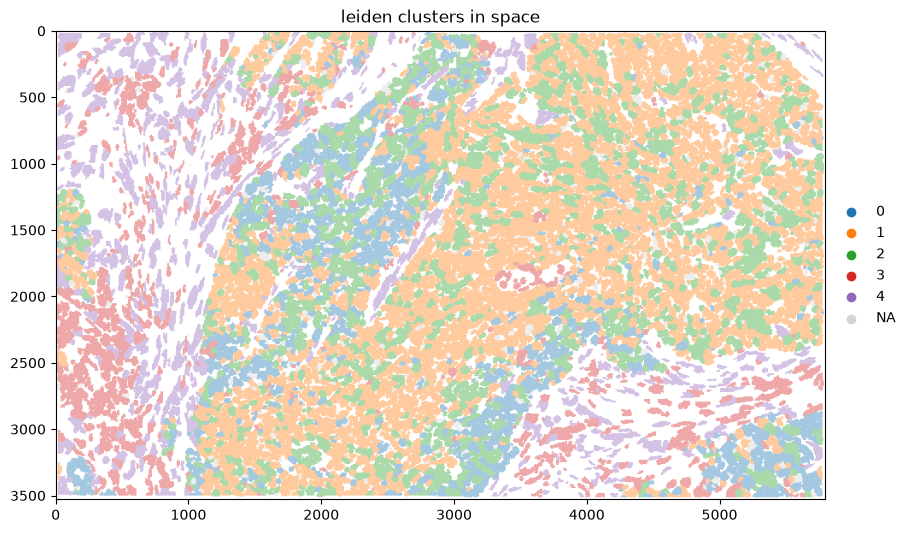

In [5]:
# Filtered-out cells stay missing rather than becoming a literal "nan" category,
# so they render as background instead of as a sixth cluster.
sdata["table"].obs["leiden"] = pd.Categorical(
    adata.obs["leiden"].reindex(sdata["table"].obs_names)
)

sdata.pl.render_labels("cell_labels", color="leiden").pl.show(
    coordinate_systems="global", title="leiden clusters in space", figsize=(9, 6)
)

## 2. The spatial graph

`sq.gr.spatial_neighbors` writes two matrices into the object: `spatial_connectivities`
(who is connected to whom) and `spatial_distances`. Everything downstream reads them.

For point-like data — cells with real coordinates rather than a regular array — use
`coord_type="generic"`. **Delaunay** triangulation connects cells that share a border in the
Voronoi tessellation, which is as close to "physically adjacent" as you get without
modelling membranes.

In [6]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)

conn = adata.obsp["spatial_connectivities"]
print(f"{conn.shape[0]} cells, {int(conn.nnz / 2)} edges")
print(f"mean degree {conn.sum(axis=1).mean():.1f}")

INFO     Creating graph using `None` transform and `1` libraries.                                                  


6906 cells, 20689 edges
mean degree 6.0


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_2284/147470795.py:1: FutureWarning: Calling `spatial_neighbors` is deprecated and will be removed in squidpy v1.9.0. Use `spatial_neighbors_knn`, `spatial_neighbors_radius`, `spatial_neighbors_delaunay`, `spatial_neighbors_grid`, or `spatial_neighbors_from_builder` instead.
  sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)


A graph is much easier to judge by eye than by summary statistic. Draw it over a small crop
and look at the edges — especially at the tissue border.

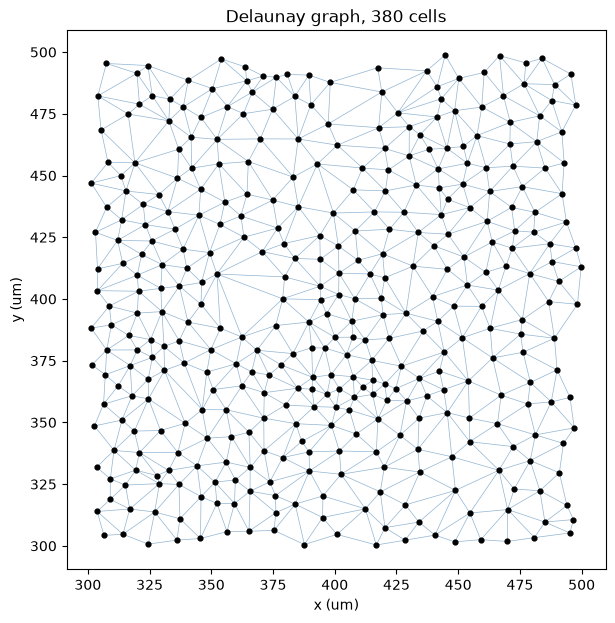

In [7]:
xy = adata.obsm["spatial"]
box = (xy[:, 0] > 300) & (xy[:, 0] < 500) & (xy[:, 1] > 300) & (xy[:, 1] < 500)
idx = np.where(box)[0]

sub = conn[idx][:, idx].tocoo()
fig, ax = plt.subplots(figsize=(7, 7))
for i, j in zip(sub.row, sub.col):
    if i < j:
        ax.plot(*zip(xy[idx[i]], xy[idx[j]]), color="steelblue", lw=0.5, alpha=0.6, zorder=1)
ax.scatter(xy[idx, 0], xy[idx, 1], s=12, color="black", zorder=2)
ax.set(title=f"Delaunay graph, {len(idx)} cells", xlabel="x (um)", ylabel="y (um)", aspect="equal")
plt.show()

> **_Question:_** Look for long edges that jump across empty space. What creates them, and
> what would they do to a neighbourhood-enrichment result?

## 3. Grids are a different problem

Visium is not point data — spots sit on a regular hexagonal lattice, so "the six
neighbours" is exactly the right answer and you should say so rather than infer it.
`coord_type="grid"` with `n_neighs=6` does that.

The same `n_neighs=6` applied to Xenium would be arbitrary: nothing about imaging-based data
says a cell has six neighbours.

In [8]:
vis = sd.read_zarr(paths.data("visium_hne.zarr"))
vadata = vis["adata"]

# the table travels without centroids; take them from the spots element
spots = vis["spots"]
vadata.obsm["spatial"] = np.c_[spots.geometry.x.values, spots.geometry.y.values]

sq.gr.spatial_neighbors(vadata, coord_type="grid", n_neighs=6)
print(f"{vadata.n_obs} spots, mean degree {vadata.obsp['spatial_connectivities'].sum(axis=1).mean():.1f}")

INFO     Creating graph using `None` transform and `1` libraries.                                                  


2688 spots, mean degree 5.8


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_2284/4020706084.py:8: FutureWarning: Calling `spatial_neighbors` is deprecated and will be removed in squidpy v1.9.0. Use `spatial_neighbors_knn`, `spatial_neighbors_radius`, `spatial_neighbors_delaunay`, `spatial_neighbors_grid`, or `spatial_neighbors_from_builder` instead.
  sq.gr.spatial_neighbors(vadata, coord_type="grid", n_neighs=6)


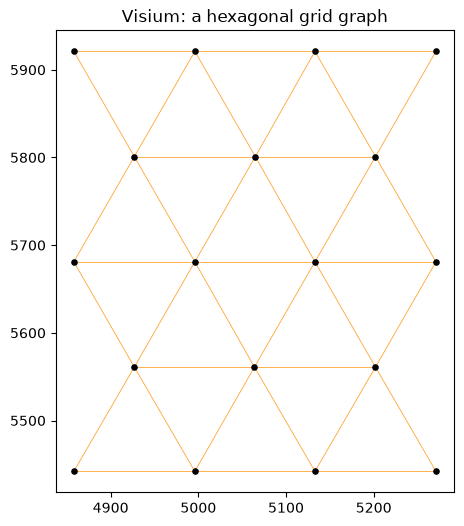

In [9]:
vxy = vadata.obsm["spatial"]
vsub = vadata.obsp["spatial_connectivities"].tocoo()
sel = (vxy[:, 0] > np.quantile(vxy[:, 0], 0.45)) & (vxy[:, 0] < np.quantile(vxy[:, 0], 0.55))
sel &= (vxy[:, 1] > np.quantile(vxy[:, 1], 0.45)) & (vxy[:, 1] < np.quantile(vxy[:, 1], 0.55))
keep_idx = set(np.where(sel)[0])

fig, ax = plt.subplots(figsize=(6, 6))
for i, j in zip(vsub.row, vsub.col):
    if i < j and i in keep_idx and j in keep_idx:
        ax.plot(*zip(vxy[i], vxy[j]), color="darkorange", lw=0.6, alpha=0.8, zorder=1)
ax.scatter(vxy[sel, 0], vxy[sel, 1], s=14, color="black", zorder=2)
ax.set(title="Visium: a hexagonal grid graph", aspect="equal")
plt.show()

## 4. Neighbourhood enrichment

The question: do cells of cluster A sit next to cells of cluster B more often than chance?

"Chance" here is a **permutation null**. Squidpy keeps the graph fixed and shuffles the
cluster labels across cells many times, counting A–B adjacencies each time. The z-score is
how far the observed count sits from that shuffled distribution.

What that null assumes is worth stating out loud: it preserves the tissue geometry and the
cluster sizes, and destroys only the assignment of labels to positions.

INFO     Creating graph using `None` transform and `1` libraries.                                                  


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_2284/2864169972.py:1: FutureWarning: Calling `spatial_neighbors` is deprecated and will be removed in squidpy v1.9.0. Use `spatial_neighbors_knn`, `spatial_neighbors_radius`, `spatial_neighbors_delaunay`, `spatial_neighbors_grid`, or `spatial_neighbors_from_builder` instead.
  sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)


  0%|          | 0/1000 [00:00<?, ?/s]

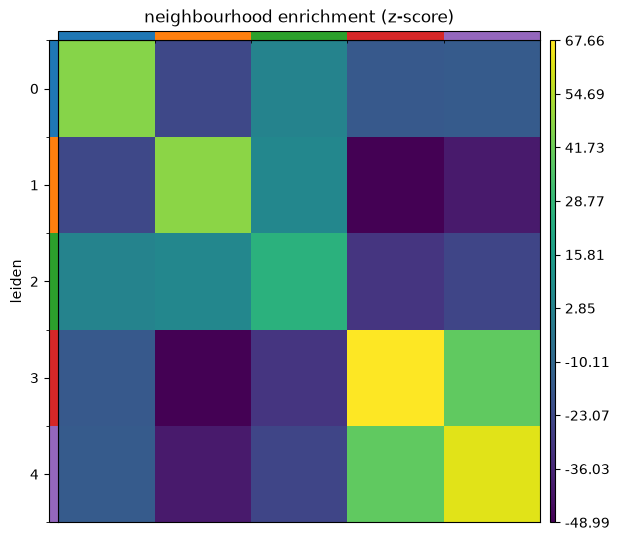

In [10]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)
sq.gr.nhood_enrichment(adata, cluster_key="leiden", seed=0)

sq.pl.nhood_enrichment(adata, cluster_key="leiden", figsize=(6, 5), title="neighbourhood enrichment (z-score)")
plt.show()

Red on the diagonal means a cluster is spatially self-associating — cells of that type sit
together, which is what a domain looks like. Strong off-diagonal red is the interesting case:
two different populations that consistently touch.

> **_Question:_** With ~7,000 cells, every one of these z-scores is "significant". What
> should you report instead of a p-value?

## 5. Co-occurrence — the same question, resolved by distance

Neighbourhood enrichment is graph-resolved: it only knows "connected or not". Co-occurrence
throws the graph away and asks how the probability of finding cluster B near cluster A
changes as a function of *radius*. When the graph is doing something you do not trust, this
is the check.

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_2284/3040941863.py:1: FutureWarning: Parameter `n_splits` of `co_occurrence()` is deprecated and has no effect. It will be removed in squidpy v1.10.0.
  sq.gr.co_occurrence(adata, cluster_key="leiden", n_splits=1)


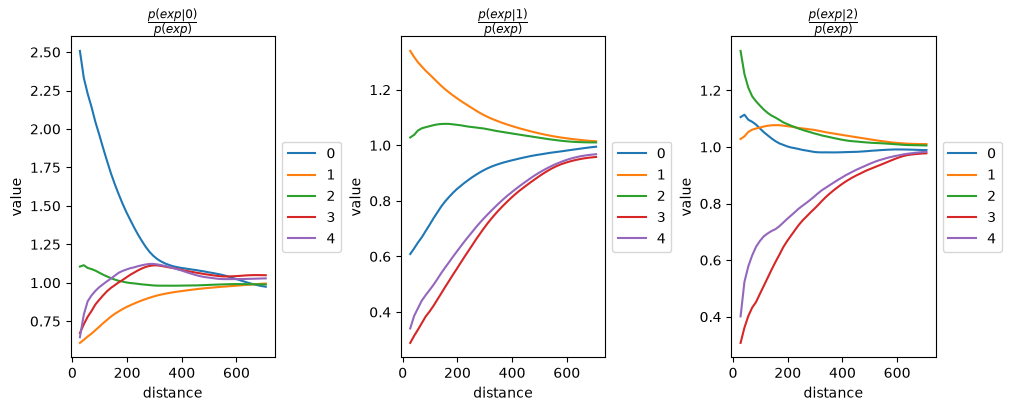

In [11]:
sq.gr.co_occurrence(adata, cluster_key="leiden", n_splits=1)

clusters = adata.obs["leiden"].cat.categories[:3].tolist()
sq.pl.co_occurrence(adata, cluster_key="leiden", clusters=clusters, figsize=(10, 4))
plt.show()

## 6. Ripley's statistics — is this cluster clustered at all?

Enrichment and co-occurrence both compare pairs of labels. Ripley's L asks a simpler thing
about a single label: is it more spatially aggregated than a random arrangement of the same
number of points? Above the null line means clustered, below means dispersed.

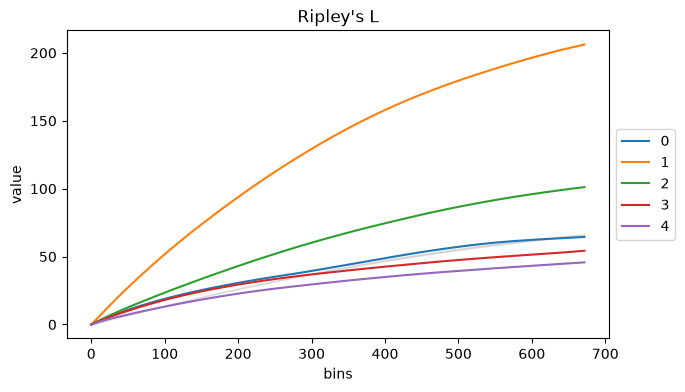

In [12]:
sq.gr.ripley(adata, cluster_key="leiden", mode="L")
sq.pl.ripley(adata, cluster_key="leiden", mode="L", figsize=(7, 4))
plt.show()

## 7. Centrality scores

Graph-theoretic summaries of each cluster's position in the spatial network: degree
centrality (how connected), closeness (how central), clustering coefficient (how much its
neighbours are neighbours of each other). Useful as a compact fingerprint of spatial
organisation.

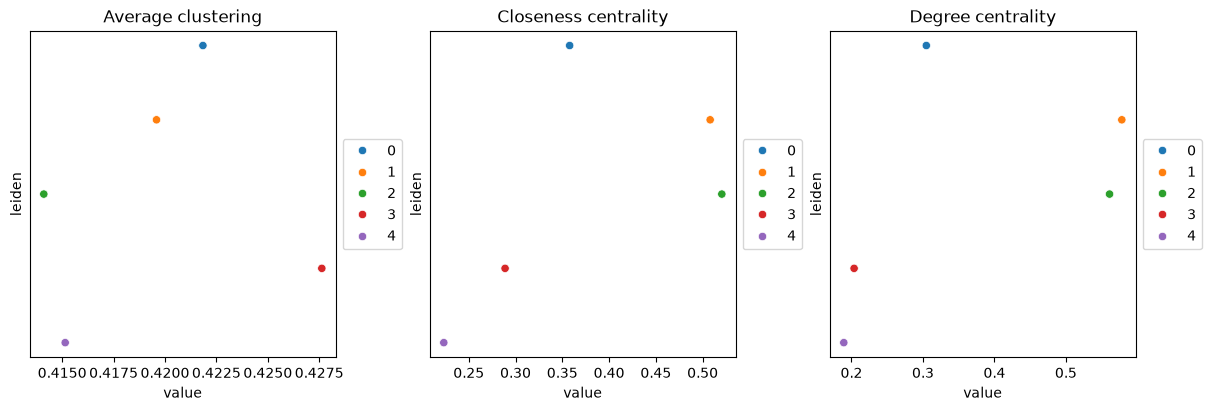

In [13]:
sq.gr.centrality_scores(adata, cluster_key="leiden")
sq.pl.centrality_scores(adata, cluster_key="leiden", figsize=(12, 4))
plt.show()

### Exercise

The point of this exercise is to show that the graph is a modelling choice, not a technical
detail.

1. Build the spatial graph three ways on the same object:
   - `delaunay=True`
   - `n_neighs=6` (k-nearest neighbours)
   - `radius=30` (everything within 30 um)
   Record the number of edges and the mean degree of each.
2. Run `sq.gr.nhood_enrichment` after each one and plot the three heatmaps side by side.
3. Find one cluster pair whose z-score changes substantially between graphs. Which graph do
   you believe, and why?
4. Set `radius=100` and look at the graph over the crop from §2. What has gone wrong?

> **_Question:_** If the conclusion changes with the graph, was there a biological finding
> to begin with?

In [14]:
# your answer here

## Pitfalls

- **Unannotated clusters are not cell types.** Running enrichment on Leiden output and
  reading biology into it is the single most common mistake in spatial analysis. Annotate
  first, or phrase your conclusion about clusters rather than cells.
- **p-values are meaningless at this n.** Effect size and reproducibility across samples are
  the quantities that carry information.
- **Long edges silently connect unrelated regions.** Delaunay triangulates the convex hull,
  so cells on either side of a gap become "neighbours". Cap edge length with `radius` when
  the tissue has holes.
- **The graph is a hyperparameter.** Report which one you used, with its parameters, in the
  methods section.

## Further reading

- [Squidpy documentation](https://squidpy.readthedocs.io/en/stable/) and its
  [Xenium tutorial](https://squidpy.readthedocs.io/en/stable/notebooks/tutorials/tutorial_xenium.html)
- [Palla et al. (2022), *Squidpy: a scalable framework for spatial omics analysis*](https://www.nature.com/articles/s41592-021-01358-2)
- Ripley, B. D. (1977), *Modelling spatial patterns* — the original statistic